# 08. Final Bayesian Project Report — UTMB Race Data

This notebook is the final, condensed technical report for the Bayesian analysis of UTMB race data.
It summarizes what was done across notebooks 01–07 and keeps only the essential elements:

- data definition and preprocessing decisions,
- modelling motivation,
- likelihoods and priors,
- posterior diagnostics,
- posterior predictive checks,
- model comparison by LOO/WAIC,
- final conclusions and limitations.

The project contains three modelling tasks:

1. **Mean Finish Time** — log-scale regression for average race finish time.
2. **Winning Time** — log-scale regression for the winner's time.
3. **Female Participation** — bounded count modelling for the number of female participants.

The notebook is written as a report notebook. It does not repeat expensive MCMC sampling. Instead, it documents the final model design and reproduces the most important summary plots from the obtained results.


## 1. Project motivation

Ultra-trail race outcomes are not well described by a single deterministic formula. Finish times and participation structure depend on several course and context variables:

- race distance,
- elevation gain,
- route steepness,
- altitude above sea level,
- geographic location,
- year of the event,
- race category.

A Bayesian approach is appropriate here because it gives more than point predictions. It provides posterior uncertainty, allows explicit prior assumptions, supports robust likelihoods, and gives a principled comparison of competing models through approximate out-of-sample predictive performance.

The core modelling principle used in this project is: **choose a likelihood that respects the mathematical nature of the response variable**.

Therefore:

- positive continuous times are modelled on the logarithmic scale;
- counts of women are modelled conditionally on the total number of participants;
- robust likelihoods are compared against simpler baseline likelihoods.


## 2. Imports and display configuration


In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160
pd.set_option("display.max_columns", 80)

ROOT = Path(".")
FIG_DIR = ROOT


## 3. Dataset and variables

The analysis uses UTMB World Series race-level data. The cleaned project dataset is stored as `utmb_processed.csv` and contains race-level observations after filtering and preprocessing.

The important variables are:

| Variable | Meaning | Used in |
|---|---|---|
| `Race Category` | Race category: `20K`, `50K`, `100K`, `100M` | EDA, grouped PPC |
| `Distance` | Race distance in km | all models |
| `Elevation Gain` | Total positive elevation gain in m | all models |
| `Elevation` | Altitude above sea level in m | time models, participation model |
| `Mean Finish Time` | Average finish time in hours | mean-time model |
| `Winning Time` | Winner's time in hours | winning-time model |
| `N Participants` | Total number of participants | female participation model |
| `N Women` | Number of female participants | female participation model |
| `Year` | Race year | female participation model |
| `Longitude`, `Latitude` | Spatial coordinates | female participation model |

The time models use the transformed response:

$$
y_i = \log(T_i)
$$

because finish time is positive and strongly right-skewed. The female participation model uses a bounded count formulation:

$$
Y_i = NWomen_i, \qquad 0 \leq Y_i \leq NParticipants_i.
$$


### 3.1 Optional data check

This cell is intentionally lightweight. It verifies the presence of `utmb_processed.csv` and prints the basic structure if the file is available in the working directory.


In [2]:
DATA_FILE = ROOT / "utmb_processed.csv"

if DATA_FILE.exists():
    df_check = pd.read_csv(DATA_FILE)
    print(f"Loaded {DATA_FILE}: {df_check.shape[0]:,} rows x {df_check.shape[1]} columns")
    display(df_check.head())
    display(pd.DataFrame({
        "column": df_check.columns,
        "missing": [df_check[c].isna().sum() for c in df_check.columns],
        "dtype": [str(df_check[c].dtype) for c in df_check.columns],
    }))
else:
    print("utmb_processed.csv not found in this directory. This final report can still be read without rerunning the data pipeline.")


Loaded utmb_processed.csv: 36,433 rows x 24 columns


,Race Category,Distance,Elevation Gain,Mean Finish Time,Winning Time,N Participants,Year,Country,Elevation,Elevation per km,log_time,log_distance,log_elevation,steepness,distance_std,elevation_std,distance_log_std,elevation_log_std,log_steepness,steepness_std,altitude_std,log_elevation_gain,elevation_gain_std,elevation_gain_log_std
0,50K,35.2,2030,4.9722,3.1583,163,2017,ES,594.10,57.670455,1.603862,3.561046,6.388729,57.670455,-0.619089,-0.261783,-0.548826,0.553151,4.071936,0.712529,0.092551,7.616284,-0.261783,0.046309
1,50K,34.5,1630,4.5411,3.3642,81,2018,ES,594.10,47.246377,1.513169,3.540959,6.388729,47.246377,-0.636365,-0.476259,-0.581064,0.553151,3.876321,0.328911,0.092551,7.396949,-0.476259,-0.253179
2,50K,34.6,1630,4.5033,3.2142,65,2019,ES,594.10,47.109827,1.504810,3.543854,6.388729,47.109827,-0.633897,-0.476259,-0.576419,0.553151,3.873486,0.323353,0.092551,7.396949,-0.476259,-0.253179
3,20K,27.2,1660,6.3384,3.4475,53,2017,CN,1840.54,61.029412,1.846626,3.303217,7.518357,61.029412,-0.816524,-0.460174,-0.962616,1.285596,4.127609,0.821707,2.185846,7.415175,-0.460174,-0.228292
4,20K,28.1,1750,5.5513,3.3089,44,2018,CN,1840.54,62.277580,1.714032,3.335770,7.518357,62.277580,-0.794313,-0.411916,-0.910372,1.285596,4.147531,0.860777,2.185846,7.467942,-0.411916,-0.156242


,column,missing,dtype
0,Race Category,0,object
1,Distance,0,float64
2,Elevation Gain,0,int64
3,Mean Finish Time,0,float64
4,Winning Time,0,float64
5,N Participants,0,int64
6,Year,0,int64
7,Country,7,object
8,Elevation,0,float64
9,Elevation per km,0,float64


## 4. Feature engineering decisions

The final modelling pipeline uses transformed and standardized predictors.

### Time models

For mean finish time and winning time, the following predictors are used:

| Predictor | Construction | Reason |
|---|---|---|
| `distance_log_std` | standardised `log(Distance)` | distance has multiplicative effect on time |
| `elevation_log_std` | standardised `log(Elevation Gain + 1)` | elevation gain is positive and skewed |
| `steepness_std` | standardised `log1p(Elevation Gain / Distance)` | separates route steepness from total elevation |
| `altitude_std` | standardised `log1p(Elevation)` | altitude may affect performance through physiological load |

### Female participation model

The participation model extends the predictors with location and time:

| Predictor | Reason |
|---|---|
| `longitude_std`, `latitude_std` | geographic differences in race regions and participation patterns |
| `year_std` | female participation is expected to change over time |

All predictors are standardized, so coefficients are interpreted per one standard deviation increase in the predictor.


## 5. Modelling strategy overview

The project compares simple baseline models against more flexible or robust alternatives.

| Task | Baseline model | Robust/flexible model | Main reason for comparison |
|---|---|---|---|
| Mean Finish Time | Normal regression on `log(Mean Finish Time)` | Student-t regression on `log(Mean Finish Time)` | check whether heavy-tailed residuals improve predictive fit |
| Winning Time | Normal regression on `log(Winning Time)` | Student-t regression on `log(Winning Time)` | handle outlier races and tail behaviour in elite performance |
| Female Participation | Binomial logistic regression | Beta-Binomial logistic regression | check whether race-level counts are overdispersed |

The model pairs are intentionally similar inside each task. The predictors and priors are kept comparable, while the likelihood changes. This makes LOO/WAIC comparison interpretable.


## 6. Mean Finish Time model — notebooks 02–05

### 6.1 Target and motivation

The first modelling task predicts the race-level mean finish time. The target is transformed to the logarithmic scale:

$$
y_i = \log(\mathrm{MeanFinishTime}_i)
$$

The logarithmic transformation was used because finish time is strictly positive and strongly right-skewed. A Normal regression directly on hours can produce negative predictions, while the log-scale model always gives positive predictions after back-transformation:

$$
T_i = \exp(y_i)
$$

This also makes coefficient interpretation multiplicative: a one-standard-deviation change in a predictor changes the expected time by a factor of $\exp(\beta)$.

### 6.2 Shared linear predictor

Both mean-time models use the same linear predictor:

$$
\mu_i = \alpha
+ \beta_{\mathrm{dist}} x_{\mathrm{dist},i}
+ \beta_{\mathrm{elev}} x_{\mathrm{elev},i}
+ \beta_{\mathrm{steep}} x_{\mathrm{steep},i}
+ \beta_{\mathrm{alt}} x_{\mathrm{alt},i}
$$

where:

- $x_{\mathrm{dist}}$ is standardized log-distance,
- $x_{\mathrm{elev}}$ is standardized log-elevation gain,
- $x_{\mathrm{steep}}$ is standardized route steepness,
- $x_{\mathrm{alt}}$ is standardized altitude.

### 6.3 Likelihoods

Model 1 — Normal log-time regression:

$$
y_i \sim \operatorname{Normal}(\mu_i, \sigma)
$$

Model 2 — Student-t log-time regression:

$$
y_i \sim \operatorname{Student\mbox{-}t}(\nu, \mu_i, \sigma)
$$

The Student-t model is expected to be better when some races have unusually high or low finish times relative to their distance/elevation profile.

### 6.4 Priors for mean-time models

| Parameter | Prior | Interpretation |
|---|---|---|
| $\alpha$ | $\operatorname{Normal}(0, 1)$ | weak intercept prior on the log-time scale |
| $\beta_{\mathrm{dist}}$ | $\operatorname{Normal}(0.7, 0.4)$ | longer races should strongly increase time |
| $\beta_{\mathrm{elev}}$ | $\operatorname{Normal}(0.2, 0.3)$ | more elevation should generally increase time |
| $\beta_{\mathrm{steep}}$ | $\operatorname{Normal}(0.15, 0.2)$ | steeper routes should usually be slower |
| $\beta_{\mathrm{alt}}$ | $\operatorname{Normal}(0.05, 0.1)$ | mild positive altitude effect, but uncertain |
| $\sigma$ | half-Normal induced by $\sigma > 0$ and $\operatorname{Normal}(0, 0.3)$ | residual scatter on the log scale |
| $\nu$ | $2 + \operatorname{Gamma}(2, 0.1)$ | Student-t degrees of freedom constrained to finite variance |

The priors are weakly informative and are defined on standardized predictors. Since the model is fitted to log-time, a coefficient $\beta$ can be interpreted through $\exp(\beta)$ as a multiplicative change on the original time scale for a one-standard-deviation increase in the predictor.

### 6.5 Mean-time figures from notebooks 02–05

The following cell displays the most important existing figures if the notebook is run inside the repository root. These figures are not regenerated here because the original notebooks already contain the full MCMC workflow.


**fig01_target_distributions.png**

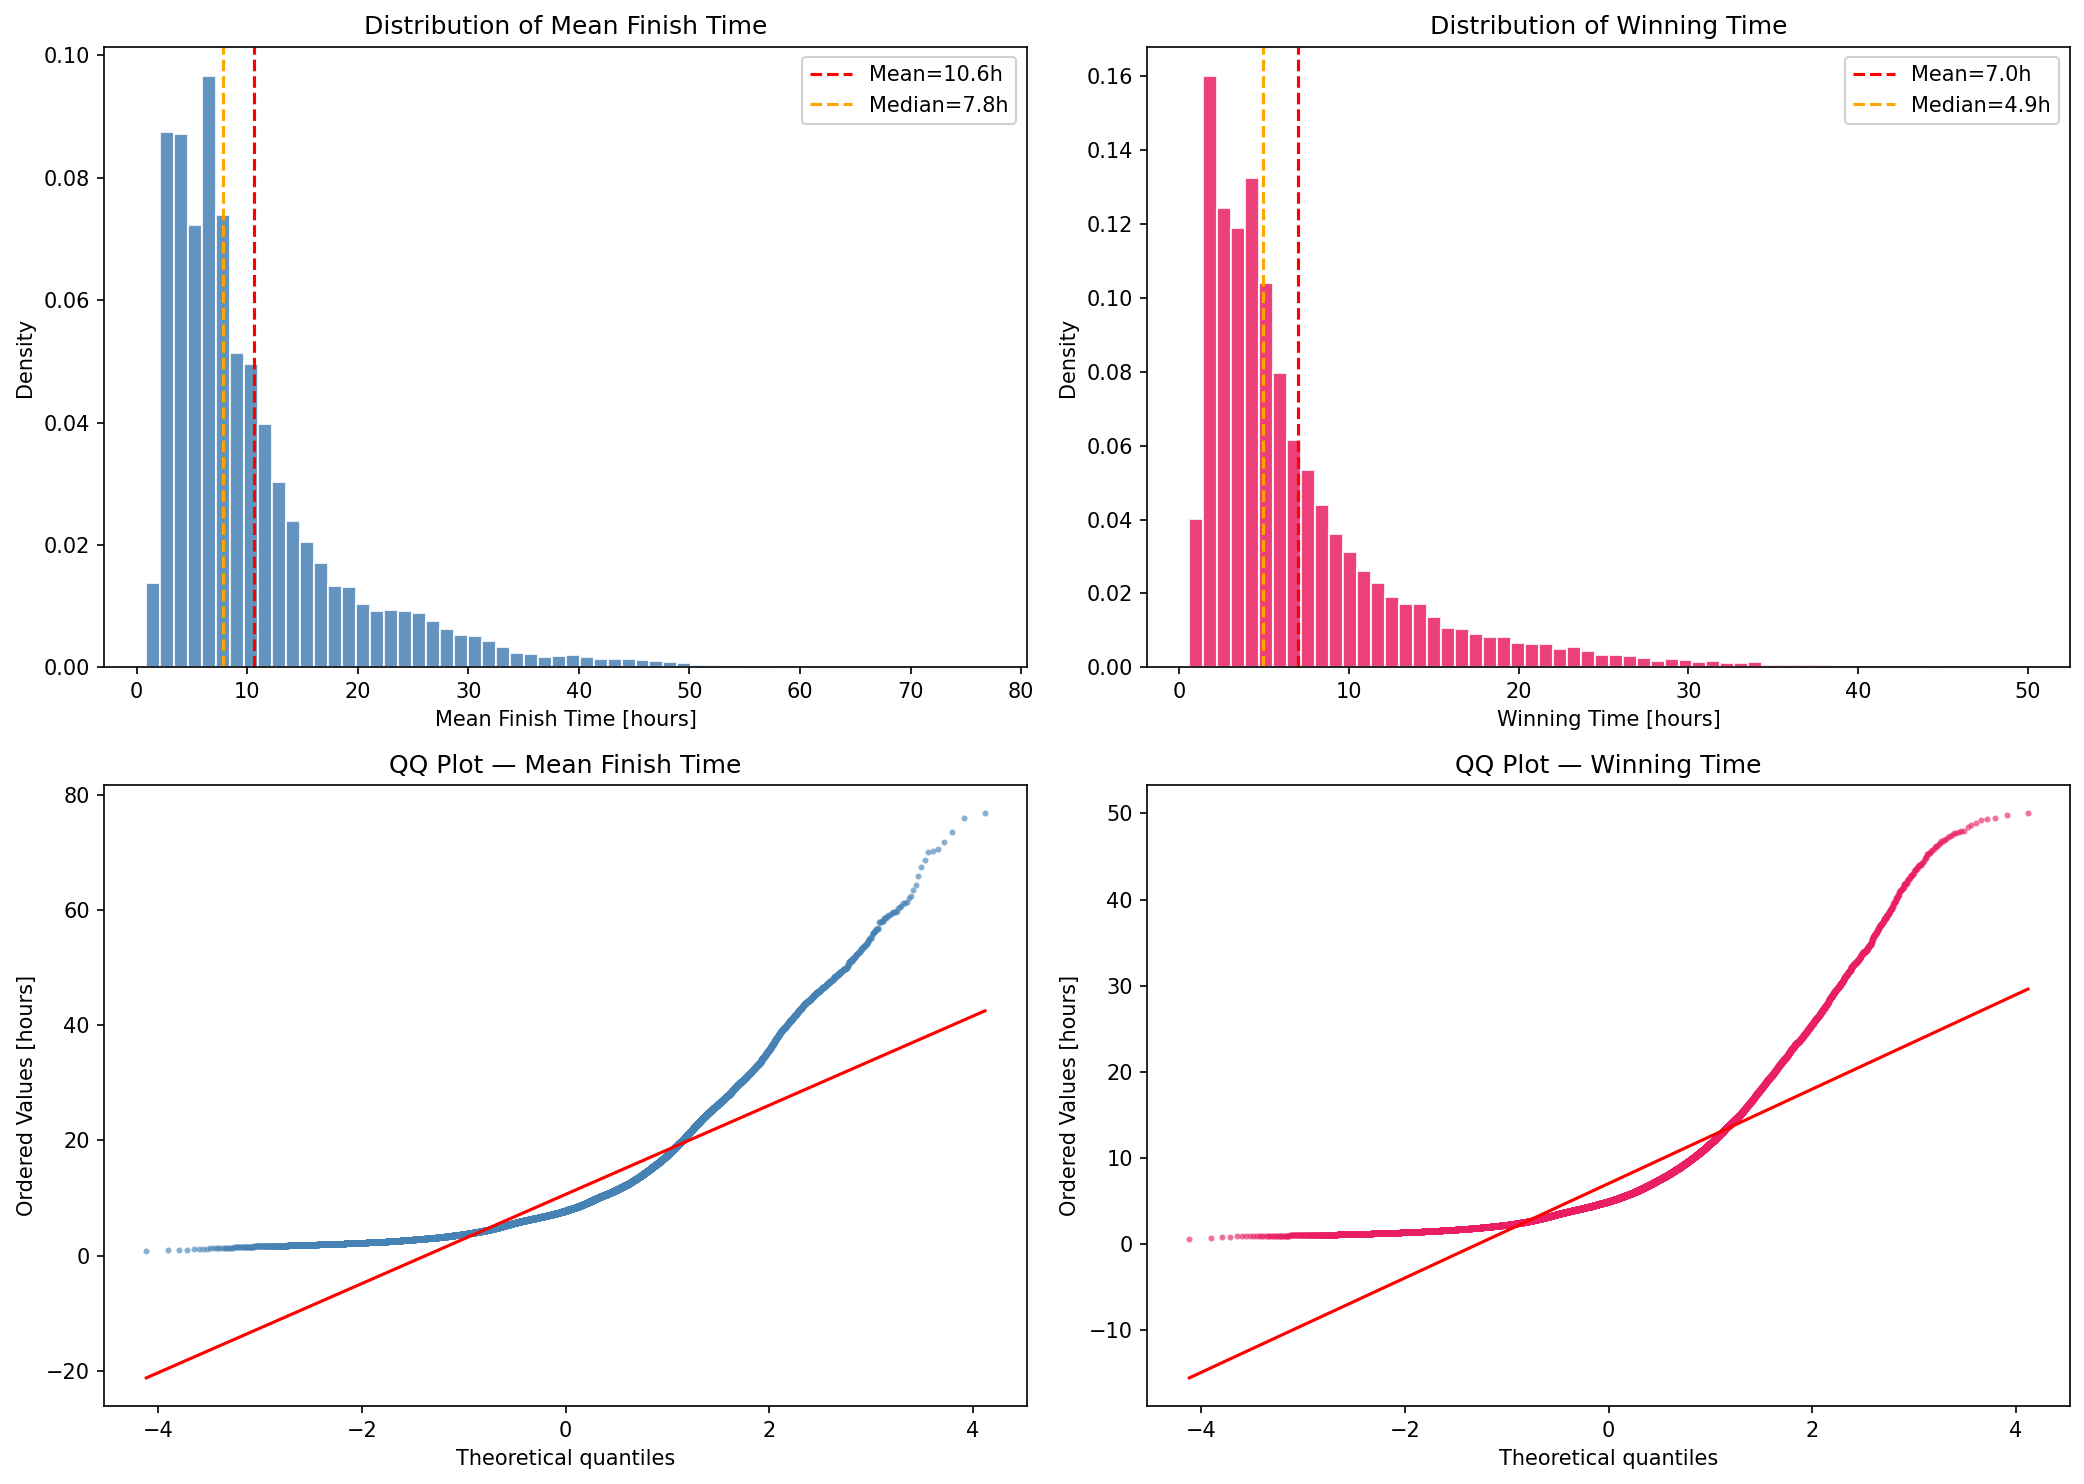

**fig04_prior_predictive_measurements.png**

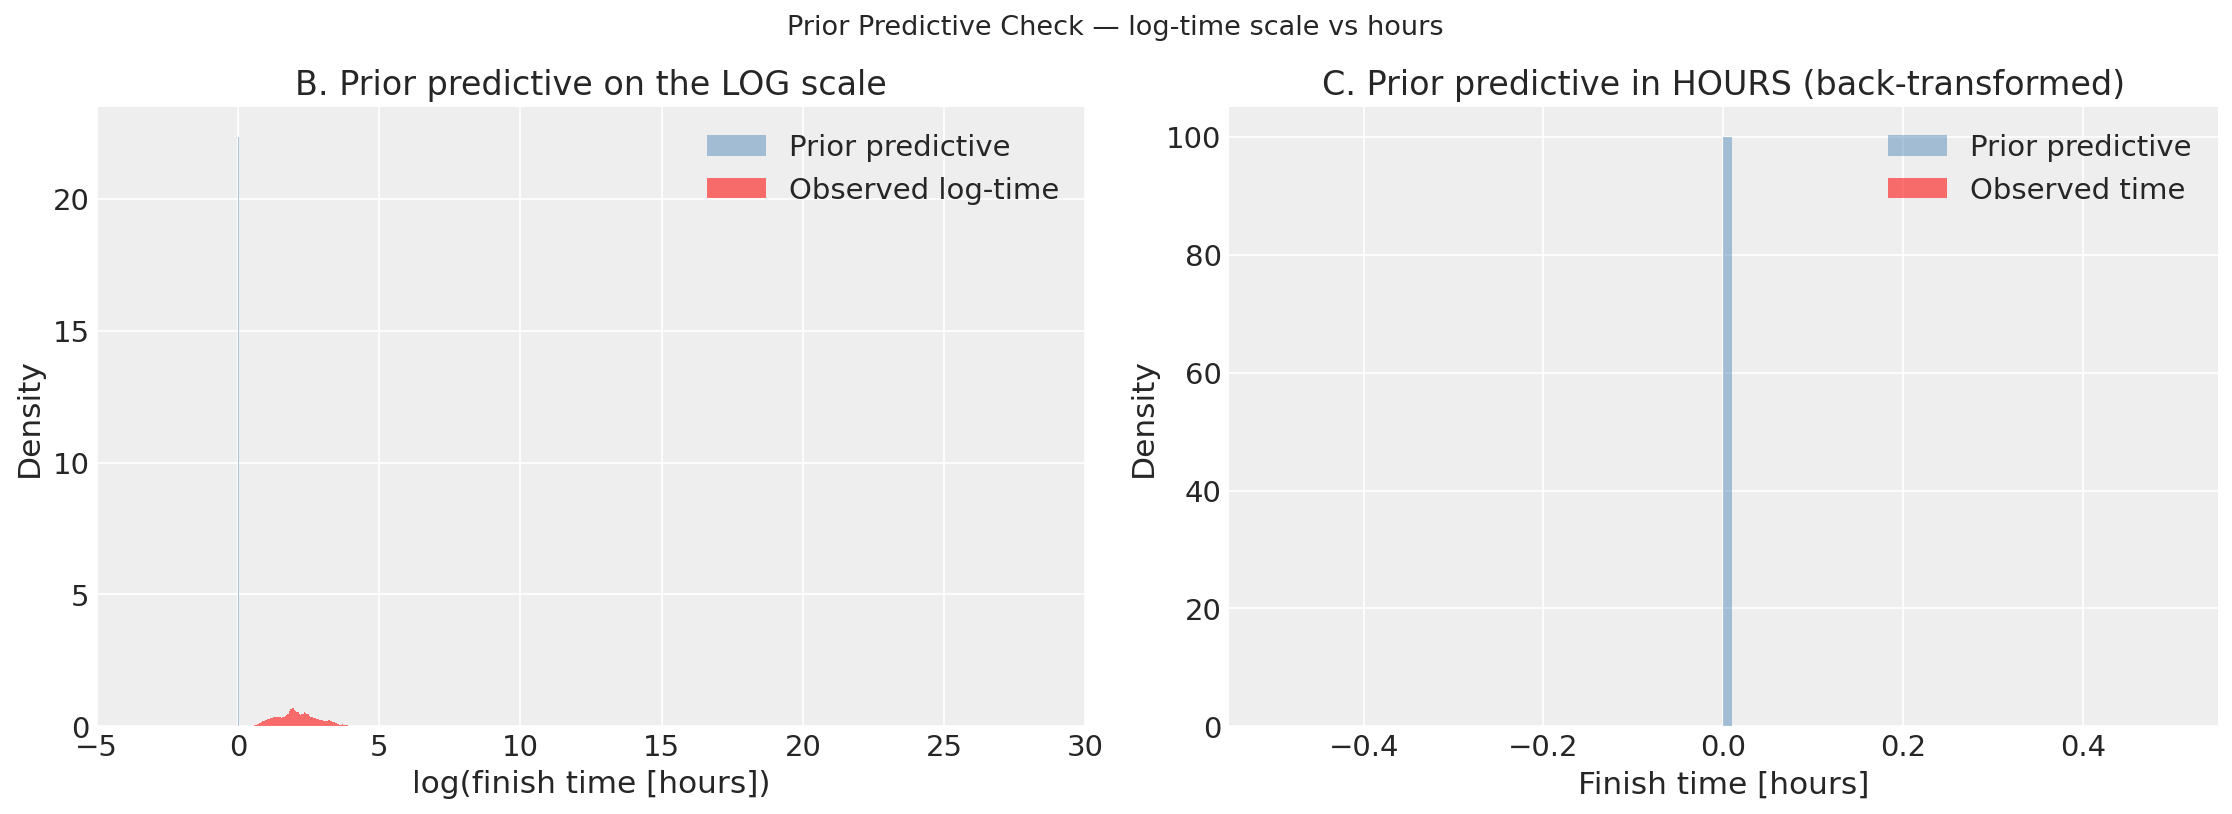

**fig06_model1_ppc_overall.png**

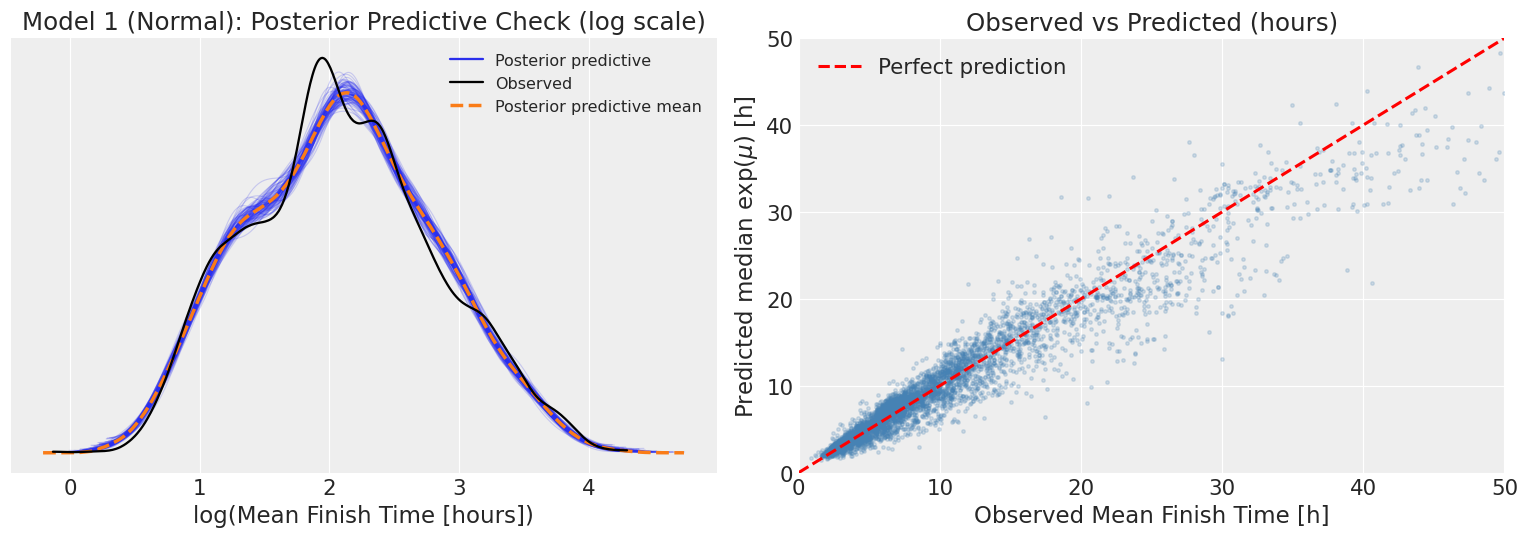

**fig12_model2_ppc_overall.png**

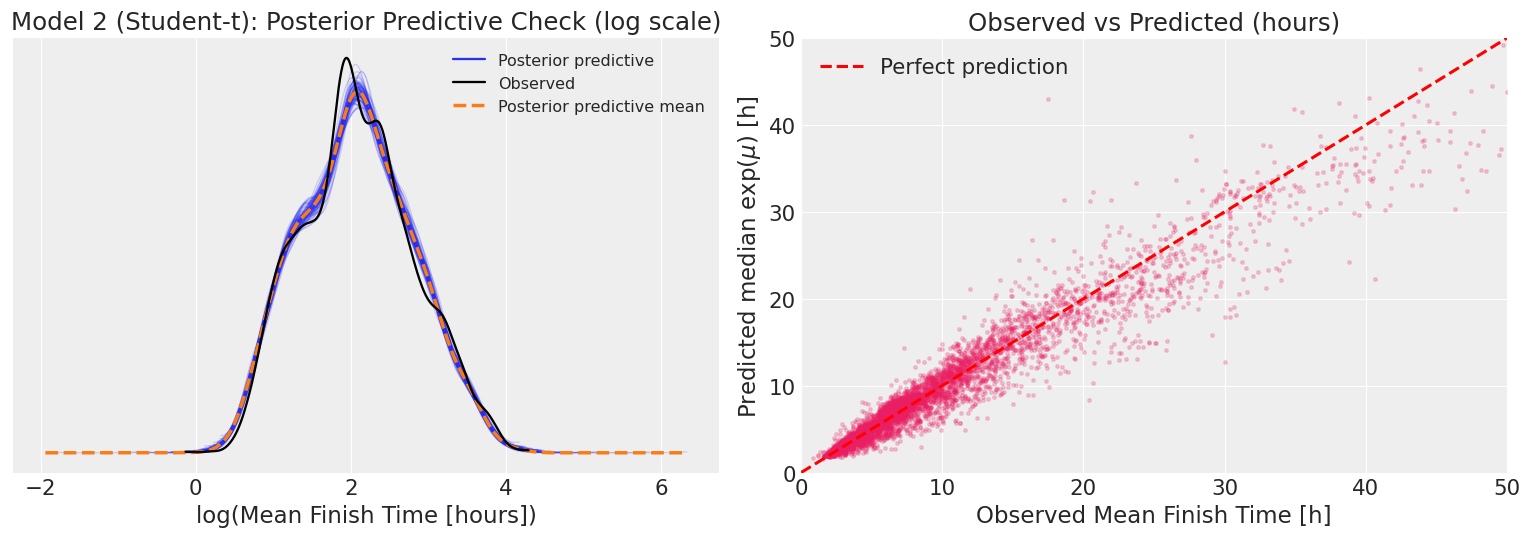

**fig18_loo_comparison.png**

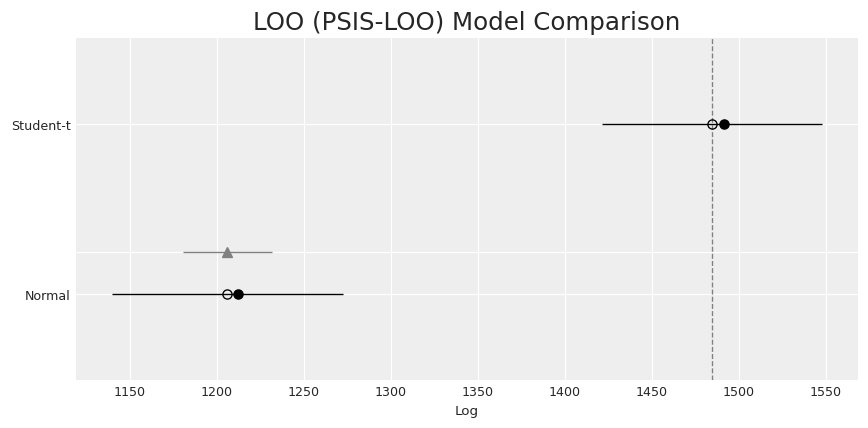

**fig19_waic_comparison.png**

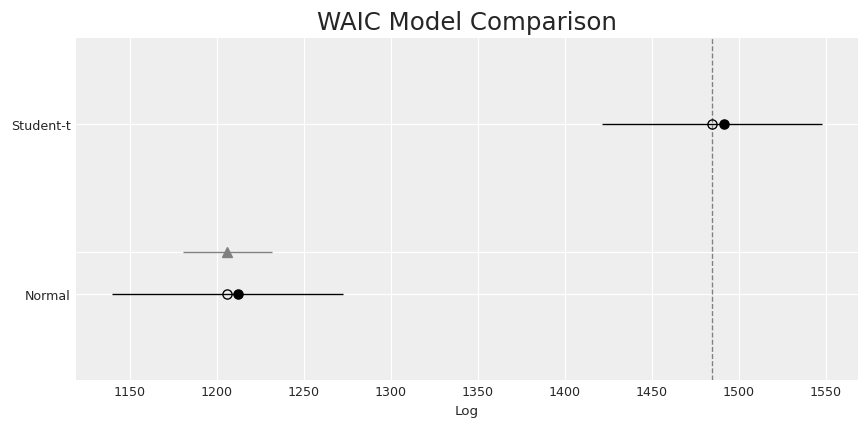

**fig20_pareto_k.png**

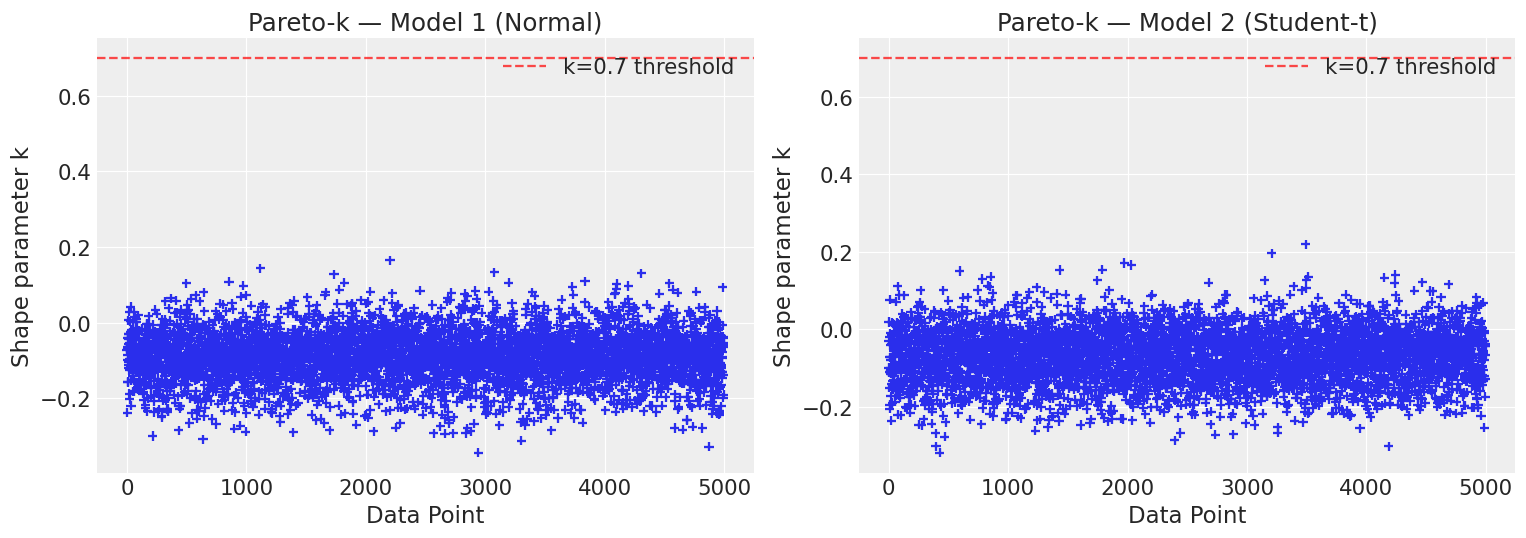

**fig21_ppc_comparison.png**

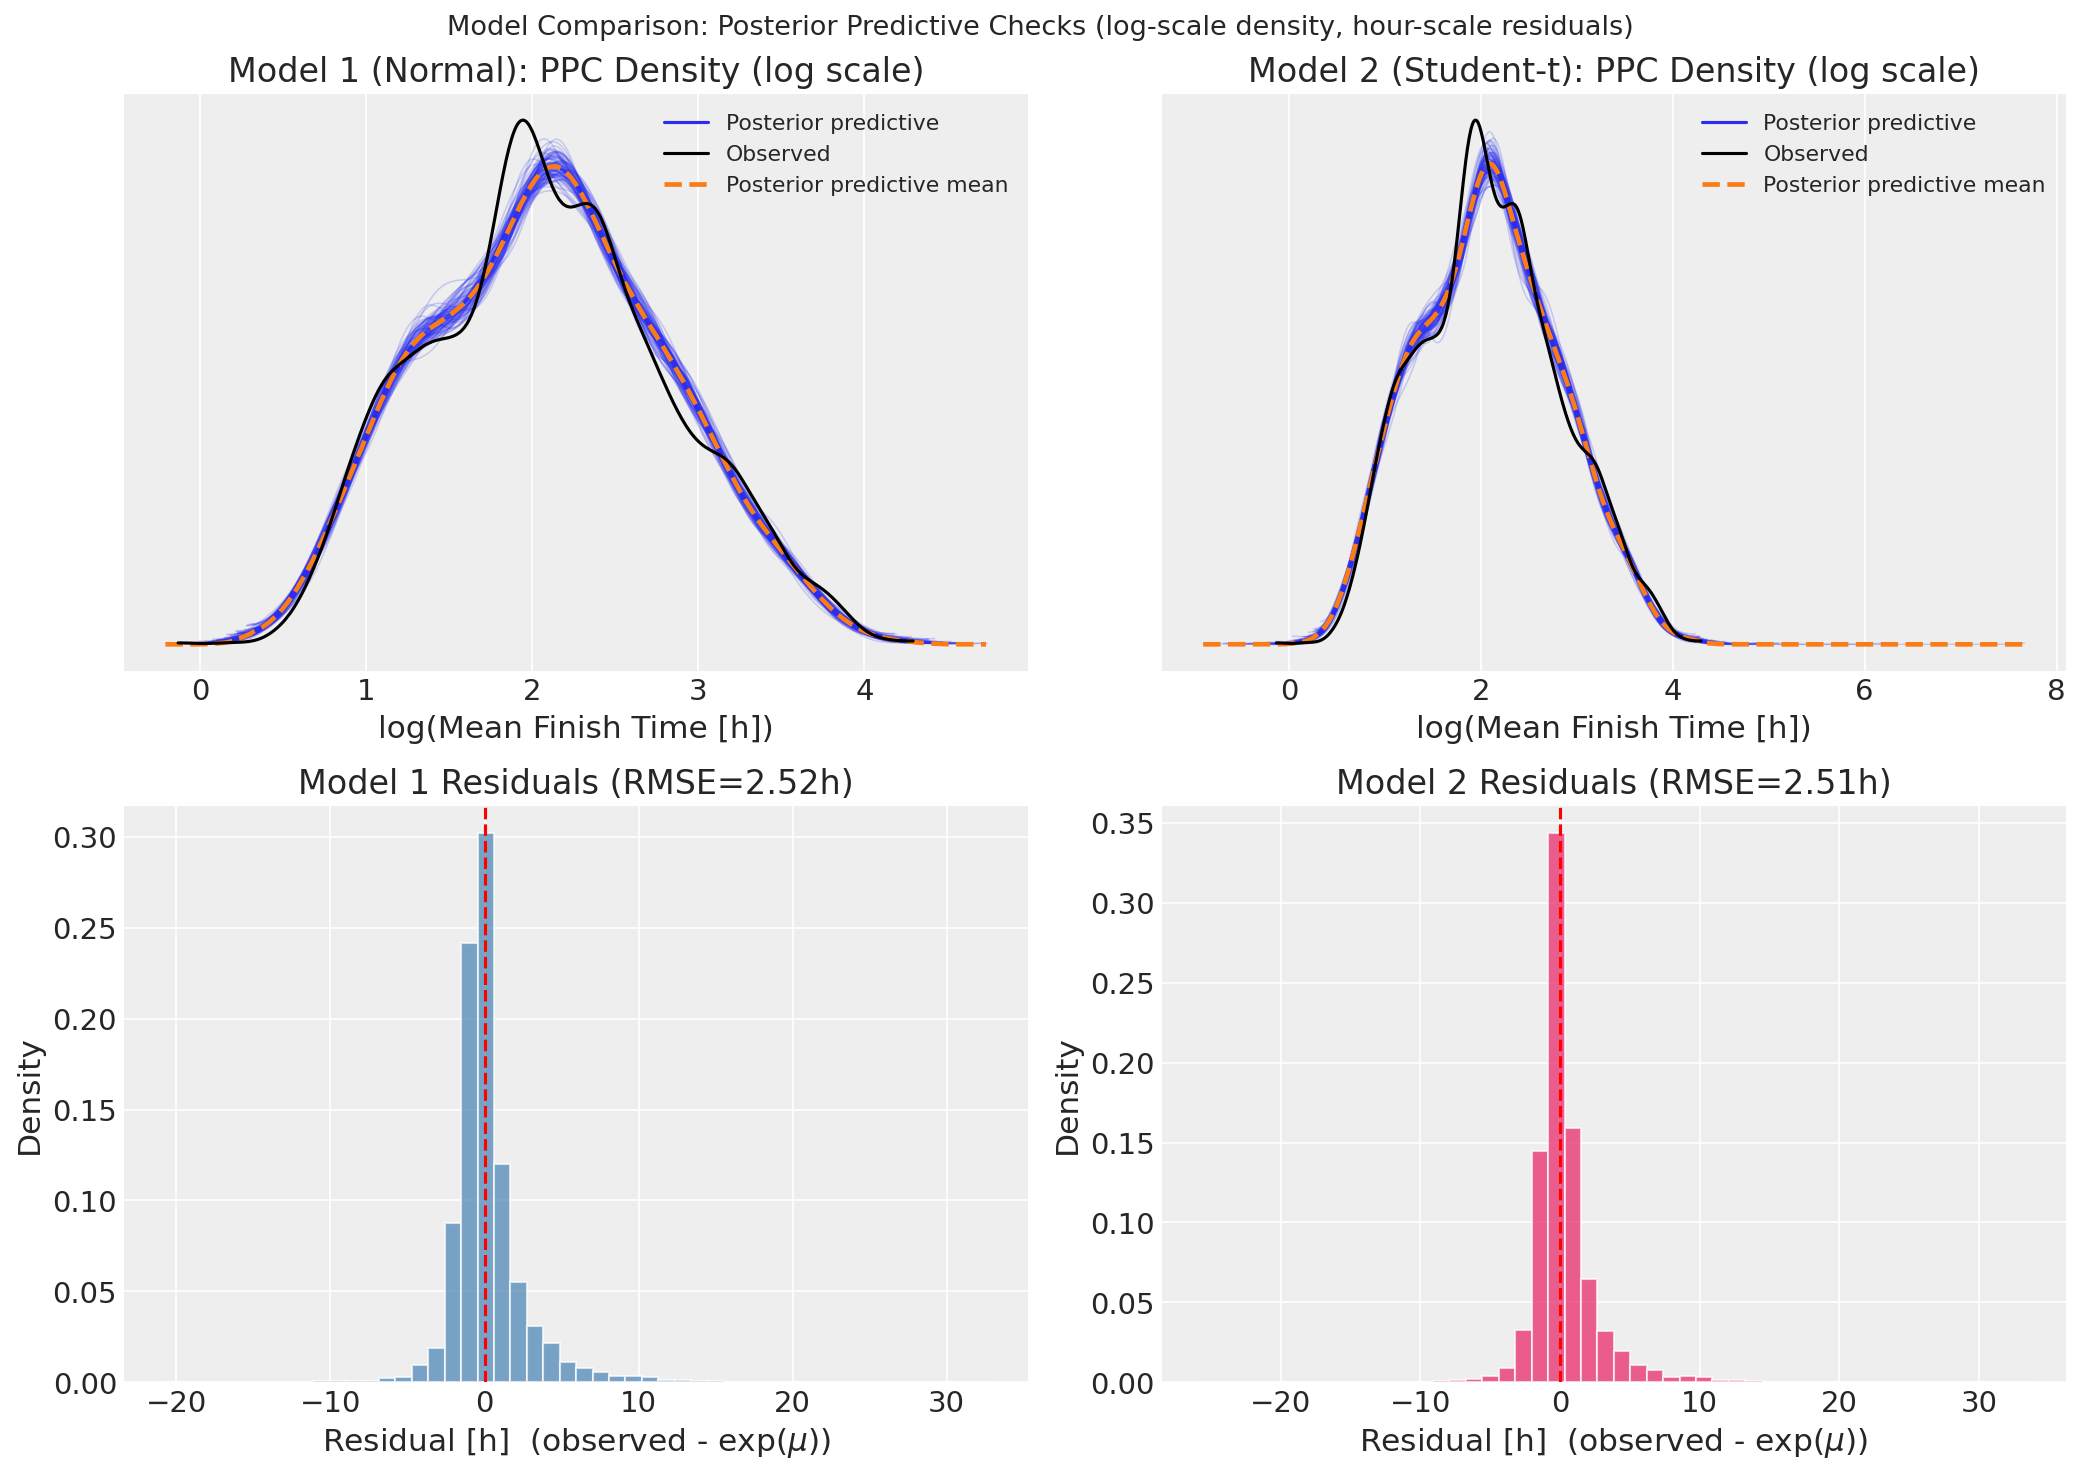

**fig22_tail_comparison.png**

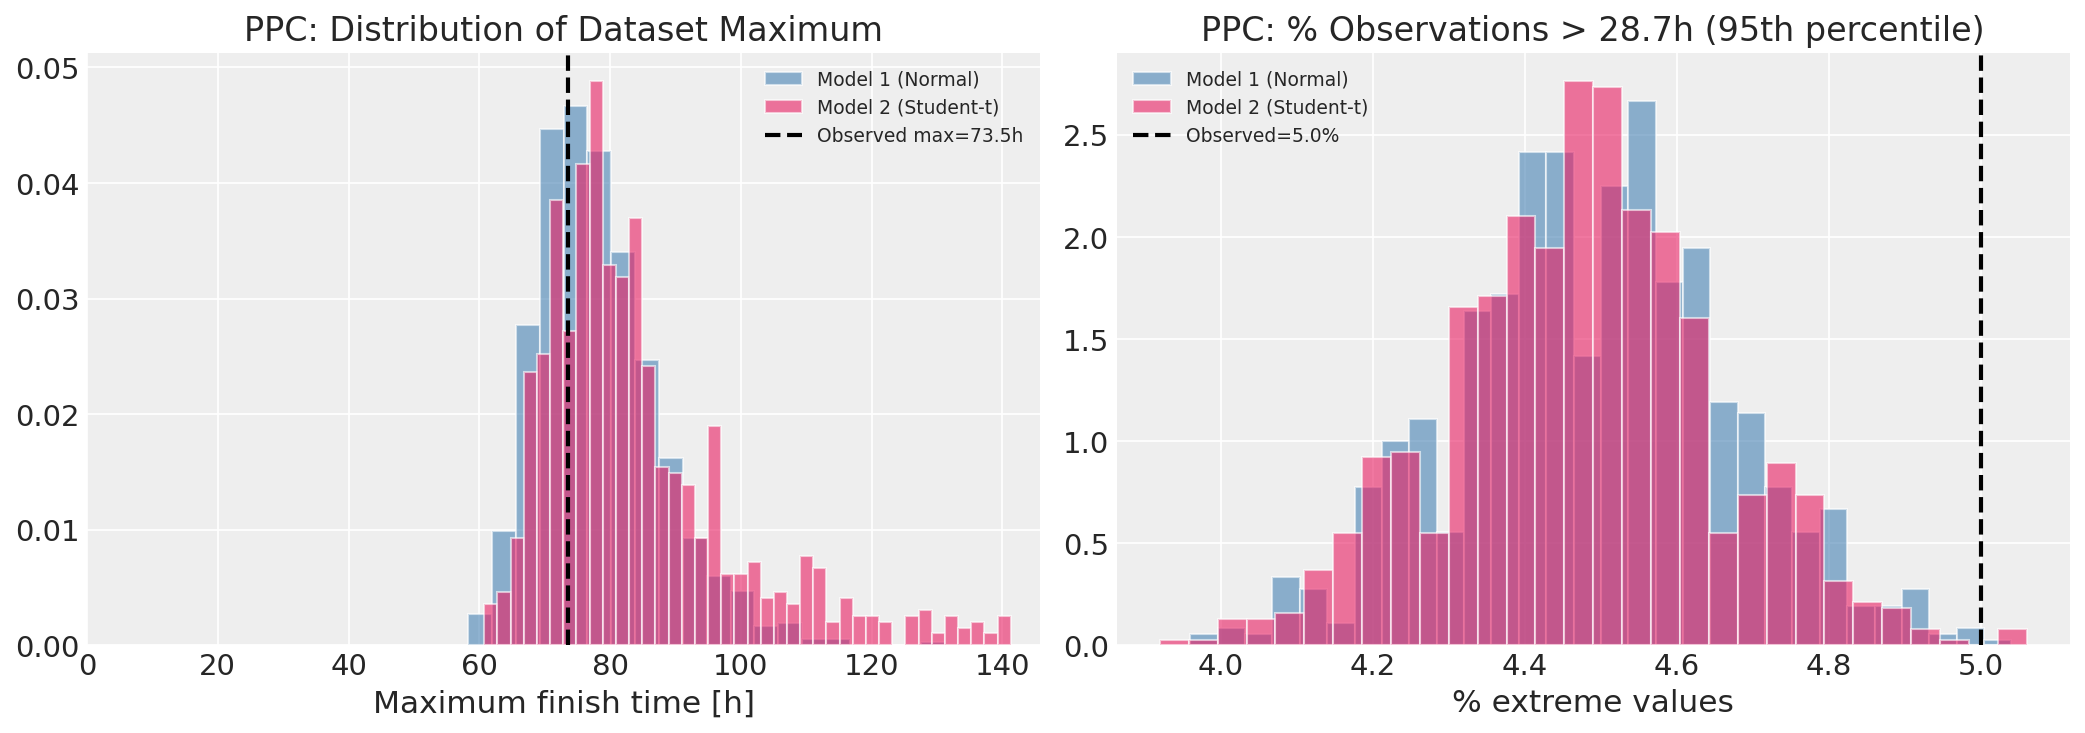

**fig23_final_comparison.png**

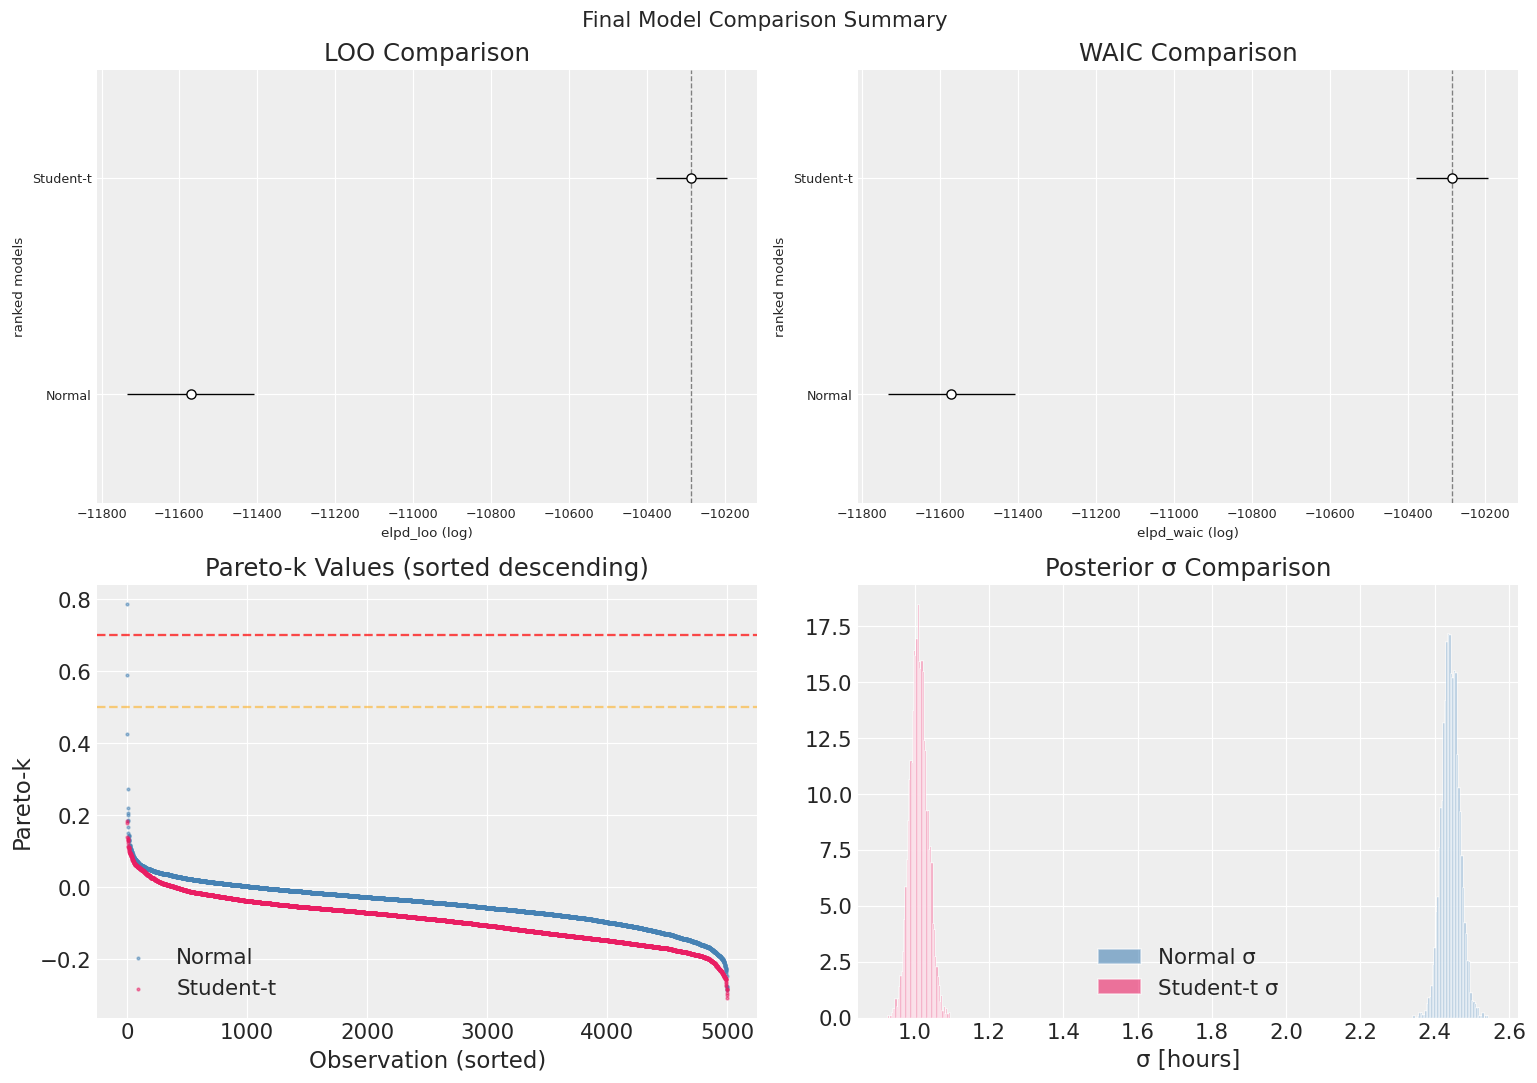

Displayed 10 mean-time figures.


In [3]:
mean_time_figures = [
    "fig01_target_distributions.png",
    "fig04_prior_predictive_measurements.png",
    "fig06_model1_ppc_overall.png",
    "fig12_model2_ppc_overall.png",
    "fig18_loo_comparison.png",
    "fig19_waic_comparison.png",
    "fig20_pareto_k.png",
    "fig21_ppc_comparison.png",
    "fig22_tail_comparison.png",
    "fig23_final_comparison.png",
]

shown = 0
for fname in mean_time_figures:
    path = FIG_DIR / fname
    if path.exists():
        shown += 1
        display(Markdown(f"**{fname}**"))
        display(Image(filename=str(path)))

if shown == 0:
    print("No repository figures found in the current directory. Run this notebook from the repository root to display the mean-time figures.")
else:
    print(f"Displayed {shown} mean-time figures.")


### 6.6 Mean-time result interpretation

The mean-time workflow shows that the log-scale formulation is the correct modelling direction for finish times. It prevents impossible negative predictions and makes the residual distribution easier to model.

The comparison in notebook 05 selects the Student-t model as the stronger model. The reason is not that the mean structure changed — it did not. The improvement comes from the likelihood: the Student-t distribution handles outlying races without inflating the residual scale for the majority of typical races.

The important modelling conclusion is:

> For average race finish time, the robust Student-t log-scale model should be preferred over the Normal log-scale baseline.

Remaining limitation: the linear predictor still cannot capture all race-specific structure. Race-category or hierarchical effects would be a natural extension.


## 7. Winning Time model — notebook 06

### 7.1 Target and motivation

The second modelling task predicts the winner's finish time. The target is again transformed to the logarithmic scale:

$$
y_i = \log(\mathrm{WinningTime}_i)
$$

This decision mirrors the mean-time workflow. The raw `Winning Time` distribution is strongly right-skewed, while `log_winning_time` is much closer to symmetric. In the executed notebook:

| Quantity | Raw winning time | Log winning time |
|---|---:|---:|
| Skewness | 2.232 | 0.242 |
| Excess kurtosis | 6.407 | -0.480 |

This strongly supports log-scale modelling.

### 7.2 Likelihoods

Model 3 — Normal log-winning-time regression:

$$
y_i \sim \operatorname{Normal}(\mu_i, \sigma)
$$

Model 4 — Student-t log-winning-time regression:

$$
y_i \sim \operatorname{Student\mbox{-}t}(\nu, \mu_i, \sigma)
$$

Both models use the same predictor set as the mean-time models:

$$
\mu_i = \alpha
+ \beta_{\mathrm{dist}} x_{\mathrm{dist},i}
+ \beta_{\mathrm{elev}} x_{\mathrm{elev},i}
+ \beta_{\mathrm{steep}} x_{\mathrm{steep},i}
+ \beta_{\mathrm{alt}} x_{\mathrm{alt},i}
$$

The model therefore explains elite performance using distance, elevation gain, route steepness and altitude, exactly parallel to the mean-time formulation.

### 7.3 Priors for winning-time models

The winning-time models use the same prior structure as the mean-time models because both tasks describe race duration on the log scale:

| Parameter | Prior | Reason |
|---|---|---|
| $\alpha$ | $\operatorname{Normal}(0, 1)$ | weak log-scale intercept |
| $\beta_{\mathrm{dist}}$ | $\operatorname{Normal}(0.7, 0.4)$ | strong positive time effect of distance |
| $\beta_{\mathrm{elev}}$ | $\operatorname{Normal}(0.2, 0.3)$ | weak-to-moderate elevation effect |
| $\beta_{\mathrm{steep}}$ | $\operatorname{Normal}(0.15, 0.2)$ | route steepness should slow runners |
| $\beta_{\mathrm{alt}}$ | $\operatorname{Normal}(0.05, 0.1)$ | mild altitude effect |
| $\sigma$ | half-Normal induced by $\sigma > 0$ and $\operatorname{Normal}(0, 0.3)$ | residual scatter on the log-time scale |
| $\nu$ | $2 + \operatorname{Gamma}(2, 0.1)$ | robust tail thickness with finite variance |

The prior predictive check produced broad but plausible finish-time distributions. The priors did not force the observed distribution before fitting, which is desirable.

### 7.4 Winning-time posterior results

Key posterior summaries from the executed notebook:

| Parameter | Normal mean | Student-t mean | Interpretation |
|---|---:|---:|---|
| $\alpha$ | 1.644 | 1.626 | baseline log winning time |
| $\beta_{\mathrm{dist}}$ | 2.373 | 2.393 | dominant positive effect of distance |
| $\beta_{\mathrm{elev}}$ | -1.874 | -1.896 | negative after controlling for distance and steepness; likely collinearity/suppression |
| $\beta_{\mathrm{steep}}$ | 1.497 | 1.510 | strong positive effect of steepness |
| $\beta_{\mathrm{alt}}$ | -0.010 | -0.010 | practically tiny altitude effect in this specification |
| $\sigma$ | 0.183 | 0.146 | Student-t leaves smaller residual scale |
| $\nu$ | — | 5.415 | moderate heavy tails |

The coefficient signs must be interpreted jointly. Elevation gain, distance and steepness are highly related in trail races. A negative coefficient for elevation gain after controlling for distance and steepness does **not** mean that climbing is physically easier. It means that, at fixed distance and fixed steepness-related structure, the remaining independent effect of the standardized elevation variable is negative in this linear specification.

### 7.5 Winning-time model comparison


,model,elpd_loo,elpd_waic,weight_loo,max_pareto_k
0,Normal,1394.778,1394.787,0.042,0.13
1,Student-t,1540.865,1540.874,0.958,0.19


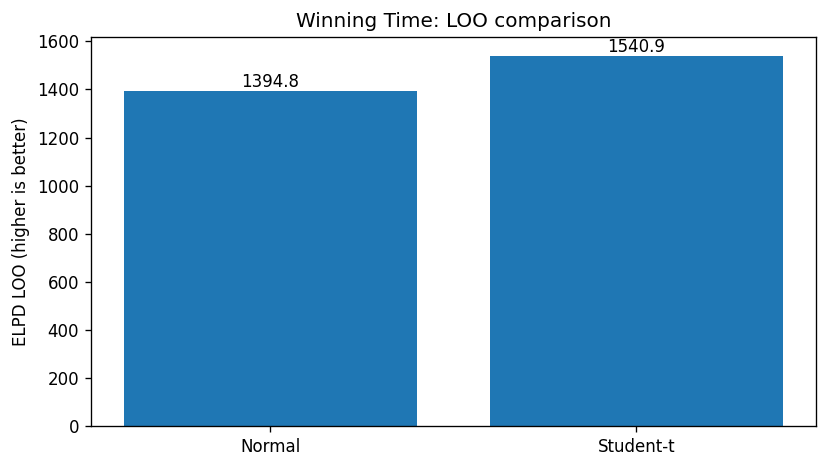

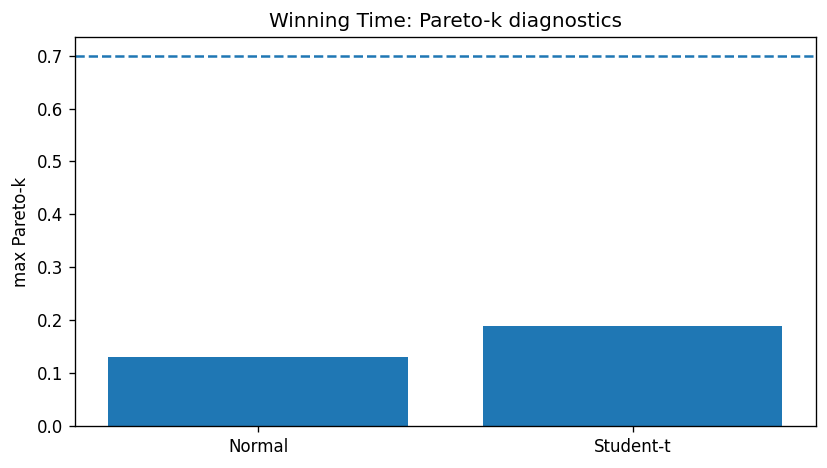

In [4]:
winning_loo = pd.DataFrame({
    "model": ["Normal", "Student-t"],
    "elpd_loo": [1394.778, 1540.865],
    "elpd_waic": [1394.787, 1540.874],
    "weight_loo": [0.042, 0.958],
    "max_pareto_k": [0.130, 0.190],
})

display(winning_loo)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(winning_loo["model"], winning_loo["elpd_loo"])
ax.set_ylabel("ELPD LOO (higher is better)")
ax.set_title("Winning Time: LOO comparison")
for idx, row in winning_loo.iterrows():
    ax.text(idx, row["elpd_loo"], f'{row["elpd_loo"]:.1f}', ha="center", va="bottom")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(winning_loo["model"], winning_loo["max_pareto_k"])
ax.axhline(0.7, linestyle="--")
ax.set_ylabel("max Pareto-k")
ax.set_title("Winning Time: Pareto-k diagnostics")
plt.tight_layout()
plt.show()


### 7.6 Winning-time posterior coefficient effects

Because the model is fitted on the log scale, $\exp(\beta)$ is a multiplicative factor on the original hour scale for a one-standard-deviation increase in the predictor.

The plotted effects should be interpreted as relative time multipliers, not as additive changes in hours. For example, a value above 1 means longer predicted winning time, while a value below 1 means shorter predicted winning time, conditional on the other predictors.

,parameter,factor_mean,hdi_3,hdi_97
0,distance,10.987,9.124,12.937
1,elevation,0.151,0.124,0.185
2,steepness,4.542,3.887,5.210
3,altitude,0.990,0.986,0.995


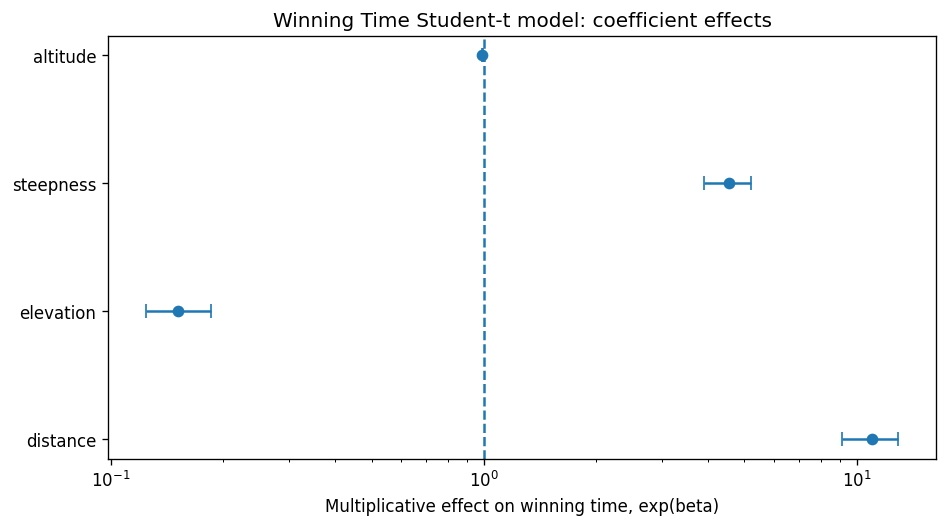

In [5]:
winning_effects = pd.DataFrame({
    "parameter": ["distance", "elevation", "steepness", "altitude"],
    "factor_mean": [10.987, 0.151, 4.542, 0.990],
    "hdi_3": [9.124, 0.124, 3.887, 0.986],
    "hdi_97": [12.937, 0.185, 5.210, 0.995],
})

display(winning_effects)

fig, ax = plt.subplots(figsize=(8, 4.5))
ypos = np.arange(len(winning_effects))
means = winning_effects["factor_mean"].values
low = winning_effects["hdi_3"].values
high = winning_effects["hdi_97"].values
ax.errorbar(means, ypos, xerr=[means - low, high - means], fmt="o", capsize=4)
ax.axvline(1.0, linestyle="--")
ax.set_yticks(ypos)
ax.set_yticklabels(winning_effects["parameter"])
ax.set_xscale("log")
ax.set_xlabel("Multiplicative effect on winning time, exp(beta)")
ax.set_title("Winning Time Student-t model: coefficient effects")
plt.tight_layout()
plt.show()


### 7.7 Winning-time PPC interpretation

The Student-t model is selected by both LOO and WAIC:

- ELPD LOO improves from **1394.78** to **1540.87**.
- LOO model weight is approximately **0.958** for Student-t.
- Pareto-k diagnostics are good for both models; no observations exceed 0.7.
- Student-t estimates smaller residual scatter: $\sigma \approx 0.146$ instead of $0.183$.

However, the posterior predictive checks show that both models still slightly underpredict the upper tail. For example, the observed 95th percentile is approximately **19.89 h**, while the Student-t posterior predictive mean is approximately **18.89 h**. The longest `100M` races are also underpredicted.

Final conclusion for winning time:

> Use the Student-t log-scale model as the preferred model, but consider race-category or hierarchical effects as the next improvement.

## 8. Female participation model — notebook 07

### 8.1 Target and motivation

The third modelling task explains the number of women participating in each race:

$$
Y_i = \mathrm{NWomen}_i
$$

This is a bounded count because the number of women cannot exceed the total number of participants:

$$
0 \leq Y_i \leq N_i,
\qquad N_i = \mathrm{NParticipants}_i
$$

Therefore, standard linear regression is inappropriate. The model should use `N Participants` as the number of trials and estimate the probability that a participant is female.

### 8.2 Likelihoods

Model 7A — Binomial logistic regression:

$$
Y_i \sim \operatorname{Binomial}(N_i, p_i)
$$

Model 7B — Beta-Binomial logistic regression:

$$
Y_i \sim \operatorname{BetaBinomial}\left(N_i,\; p_i\phi,\; (1-p_i)\phi\right)
$$

The participation probability is linked to predictors through a logistic regression:

$$
\operatorname{logit}(p_i) = \alpha
+ \beta_{\mathrm{dist}}x_{\mathrm{dist},i}
+ \beta_{\mathrm{elev}}x_{\mathrm{elev},i}
+ \beta_{\mathrm{steep}}x_{\mathrm{steep},i}
+ \beta_{\mathrm{alt}}x_{\mathrm{alt},i}
+ \beta_{\mathrm{lon}}x_{\mathrm{lon},i}
+ \beta_{\mathrm{lat}}x_{\mathrm{lat},i}
+ \beta_{\mathrm{year}}x_{\mathrm{year},i}
$$

The Beta-Binomial model adds the concentration parameter $\phi$, which captures overdispersion. If $\phi$ is large, the model approaches the Binomial. If $\phi$ is smaller, race-to-race heterogeneity is stronger.

### 8.3 Priors for female participation models

| Parameter | Prior | Reason |
|---|---|---|
| $\alpha$ | $\operatorname{Normal}(\operatorname{logit}(0.25), 1)$ | baseline female share around 25%, but broad |
| $\beta_{\mathrm{dist}}$ | $\operatorname{Normal}(-0.10, 0.35)$ | longer races may reduce female share |
| $\beta_{\mathrm{elev}}$ | $\operatorname{Normal}(-0.05, 0.35)$ | harder elevation profile may reduce female share |
| $\beta_{\mathrm{steep}}$ | $\operatorname{Normal}(-0.05, 0.35)$ | steepness effect uncertain, weakly negative |
| $\beta_{\mathrm{alt}}$ | $\operatorname{Normal}(0, 0.25)$ | weak environmental prior |
| $\beta_{\mathrm{lon}}$ | $\operatorname{Normal}(0, 0.30)$ | weak spatial prior |
| $\beta_{\mathrm{lat}}$ | $\operatorname{Normal}(0, 0.30)$ | weak spatial prior |
| $\beta_{\mathrm{year}}$ | $\operatorname{Normal}(0.20, 0.25)$ | female participation may increase over time |
| $\log(\phi)$ | $\operatorname{Normal}(\log(50), 1)$ | weak prior for overdispersion; high values approximate Binomial |

The prior predictive check showed that the observed weighted female share of approximately **24.1%** lies comfortably inside the prior predictive interval. This means the priors are informative enough to encode plausible participation rates, but not restrictive.

### 8.4 Exploratory result: female share by race category


,category,female_share
0,20K,0.310
1,50K,0.221
2,100K,0.171
3,100M,0.136


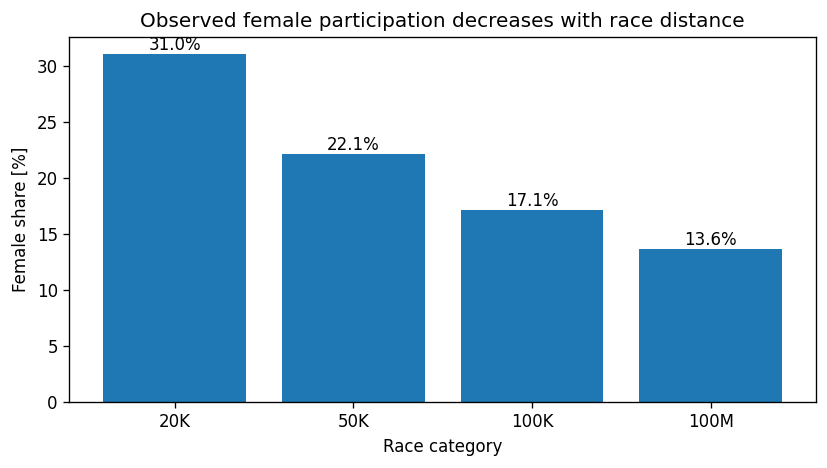

In [6]:
female_by_category = pd.DataFrame({
    "category": ["20K", "50K", "100K", "100M"],
    "female_share": [0.310, 0.221, 0.171, 0.136],
})

display(female_by_category)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(female_by_category["category"], female_by_category["female_share"] * 100)
ax.set_ylabel("Female share [%]")
ax.set_xlabel("Race category")
ax.set_title("Observed female participation decreases with race distance")
for i, row in female_by_category.iterrows():
    ax.text(i, row["female_share"] * 100, f'{row["female_share"]*100:.1f}%', ha="center", va="bottom")
plt.tight_layout()
plt.show()


### 8.5 Female participation posterior interpretation

The preferred Beta-Binomial model gives the more trustworthy coefficient interpretation because it accounts for overdispersion.

Main posterior conclusions:

- Distance has a strong negative effect: one SD increase in `distance_log_std` multiplies the odds of female participation by approximately **0.38**.
- Steepness also has a negative effect: odds ratio approximately **0.49**.
- The year effect is positive: odds ratio approximately **1.04**, indicating increasing female participation over time.
- Altitude has no strong independent effect after controlling for distance, elevation, steepness, geography and year.
- The posterior for $\phi$ concentrates around **19.5**, confirming relevant overdispersion.

### 8.6 Female participation model comparison


,model,elpd_loo,loo_weight,pareto_k_status
0,Binomial,-36294,0.007,problematic observations
1,Beta-Binomial,-18565,0.993,all below 0.7


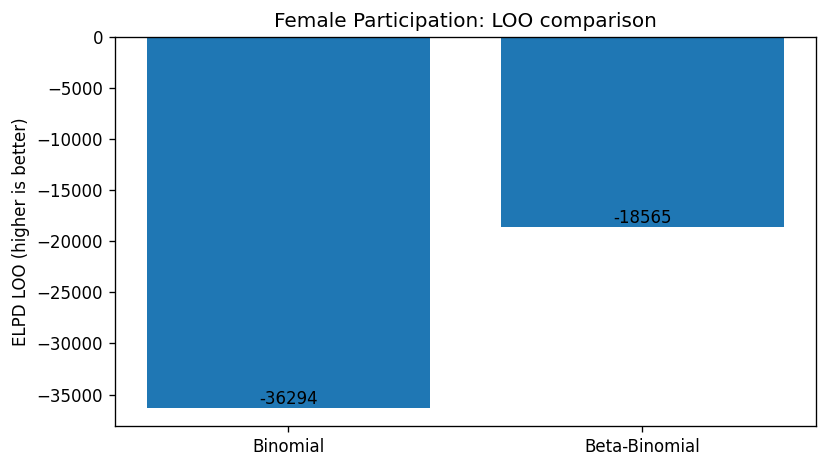

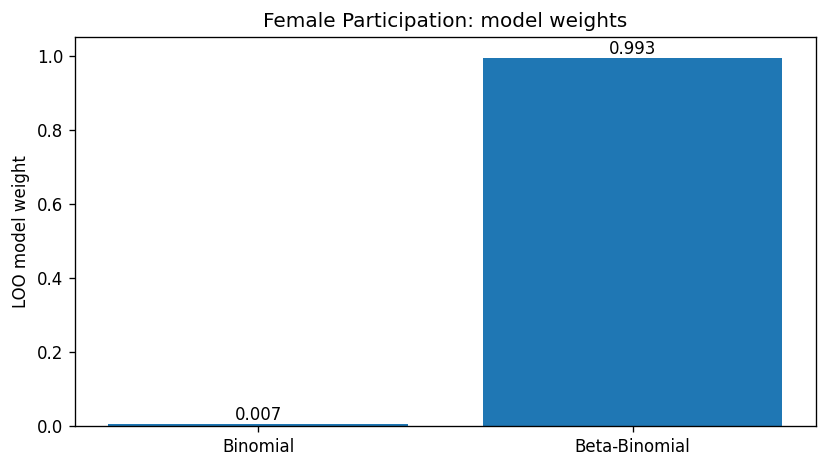

In [7]:
female_comparison = pd.DataFrame({
    "model": ["Binomial", "Beta-Binomial"],
    "elpd_loo": [-36294, -18565],
    "loo_weight": [0.007, 0.993],
    "pareto_k_status": ["problematic observations", "all below 0.7"],
})

display(female_comparison)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(female_comparison["model"], female_comparison["elpd_loo"])
ax.set_ylabel("ELPD LOO (higher is better)")
ax.set_title("Female Participation: LOO comparison")
for idx, row in female_comparison.iterrows():
    ax.text(idx, row["elpd_loo"], f'{row["elpd_loo"]:.0f}', ha="center", va="bottom")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(female_comparison["model"], female_comparison["loo_weight"])
ax.set_ylabel("LOO model weight")
ax.set_ylim(0, 1.05)
ax.set_title("Female Participation: model weights")
for idx, row in female_comparison.iterrows():
    ax.text(idx, row["loo_weight"], f'{row["loo_weight"]:.3f}', ha="center", va="bottom")
plt.tight_layout()
plt.show()


### 8.7 Female participation conclusion

The Beta-Binomial model strongly outperforms the Binomial model:

- ELPD LOO improves from about **-36,294** to **-18,565**.
- LOO weight is approximately **0.993** for Beta-Binomial.
- Pareto-k diagnostics are acceptable for Beta-Binomial but problematic for Binomial.

This is strong evidence that the data are overdispersed relative to a simple Binomial likelihood. Races with similar distance, elevation, geography and year can still have very different female participation rates.

Final conclusion for female participation:

> Use the Beta-Binomial logistic model as the preferred model. The main substantive finding is that female participation decreases with race distance and steepness, but increases over time.


## 9. Good visual representation of the Bayesian results

The project uses several plot types. Each answers a specific modelling question:

| Plot type | What it verifies | Used for |
|---|---|---|
| Target distribution before/after transform | whether log transform is justified | time models |
| Prior predictive distribution | whether priors imply plausible data before fitting | all models |
| Trace plots | whether MCMC chains mix and converge | all fitted models |
| Posterior coefficient plots | direction and uncertainty of effects | all models |
| Posterior predictive checks | whether simulated data look like observed data | all models |
| PPC summary-statistic plots | whether mean, median, tails, max are reproduced | time models |
| Grouped PPC by category | whether model works across race categories | all models |
| LOO/WAIC comparison plots | out-of-sample predictive ranking | model comparison |
| Pareto-k plot | reliability of PSIS-LOO approximation | model comparison |

The most important rule is not to show every possible plot. The report should show only plots that answer a modelling question.


## 10. Cross-task comparison


In [8]:
project_summary = pd.DataFrame({
    "task": ["Mean Finish Time", "Winning Time", "Female Participation"],
    "response": ["log(Mean Finish Time)", "log(Winning Time)", "N Women | N Participants"],
    "baseline": ["Normal", "Normal", "Binomial"],
    "preferred": ["Student-t", "Student-t", "Beta-Binomial"],
    "reason": [
        "heavy-tailed residuals / outlier races",
        "better LOO/WAIC and smaller residual scale",
        "strong overdispersion across races",
    ],
})

display(project_summary)


,task,response,baseline,preferred,reason
0,Mean Finish Time,log(Mean Finish Time),Normal,Student-t,heavy-tailed residuals / outlier races
1,Winning Time,log(Winning Time),Normal,Student-t,better LOO/WAIC and smaller residual scale
2,Female Participation,N Women | N Participants,Binomial,Beta-Binomial,strong overdispersion across races


## 11. Final conclusions

1. **Log-scale modelling is necessary for race times.**  
   Both mean finish time and winning time are positive and right-skewed. Modelling the logarithm avoids impossible negative predictions and gives multiplicative interpretation of coefficients.

2. **Student-t likelihood is preferred for time models.**  
   In both mean-time and winning-time workflows, the Student-t likelihood is more robust to atypical races. It improves predictive performance while keeping the same mean structure.

3. **Course difficulty matters, but predictors are correlated.**  
   Distance and steepness are dominant predictors. Elevation-related coefficients must be interpreted jointly because distance, total elevation gain and steepness are structurally correlated in trail-running data.

4. **Female participation requires a bounded count model.**  
   Modelling `N Women` directly as a continuous response would ignore the fact that it is bounded by `N Participants`. The Binomial/Beta-Binomial formulation is statistically appropriate.

5. **Female participation is overdispersed.**  
   The Beta-Binomial model is clearly better than the Binomial model. This means that race-level heterogeneity is larger than ordinary Binomial sampling variance.

6. **Substantive finding for participation:**  
   female share is highest in shorter races and lowest in `100M` races, while the year effect indicates increasing female participation over time.

7. **Most important future extension:**  
   add hierarchical effects for race category, country/event and year. This should improve tail fit for long races and category-level calibration.


## 12. Limitations and next modelling steps

The current models are strong baseline Bayesian models, but they are still simplified.

Main limitations:

- race-level data instead of individual runner-level data;
- no explicit hierarchical structure for race category or event;
- no direct weather, terrain technicality or aid-station information;
- linear predictor only, despite possible nonlinear effects;
- correlated predictors make some coefficients hard to interpret individually;
- some MCMC notebooks use subsampling for computational feasibility.

Recommended next steps:

1. Add varying intercepts by `Race Category`.
2. Add varying intercepts by `Country` or event family.
3. Test nonlinear effects of distance and elevation using splines.
4. For female participation, include race category explicitly instead of relying only on continuous distance/steepness.
5. Save fitted posterior objects in a reproducible format, e.g. NetCDF via ArviZ.
6. Add a lightweight script that regenerates all report figures from saved inference data.


## 13. Minimal reproducibility checklist

To make the project easier to rerun and review, the repository should contain:

- `requirements.txt` or `environment.yml`,
- separate folders: `notebooks/`, `models/`, `data/`, `figures/`, `outputs/`,
- saved ArviZ `InferenceData` files for each model,
- one final report notebook, this file,
- a short `README.md` explaining execution order.

Recommended execution order:

```text
01_problem_formulation.ipynb
02_model_specification_priors.ipynb
03_posterior_model1_normal.ipynb
04_posterior_model2_student_t.ipynb
05_model_comparison.ipynb
06_winning_time_log_modeling.ipynb
07_female_participation_modeling.ipynb
08_final_bayesian_project_report.ipynb
```
